---

**Ficha Técnica do Modelo**

| Campo | Valor |
|-------|-------|
| **Modelo** | ETS — Exponential Smoothing (Holt-Winters) |
| **Biblioteca** | `statsmodels` 0.14.6 — `ExponentialSmoothing` |
| **Hiperparâmetros configurados** | `trend='add'`, `seasonal='mul'` (ou `'add'` se valores ≤ 0), `seasonal_periods=12`, `initialization_method='estimated'`, `optimized=True` |
| **Busca de hiperparâmetros** | Não (smoothing α, β, γ otimizados internamente via MLE pelo statsmodels) |
| **Critério de seleção** | MLE — parâmetros otimizados internamente (`optimized=True`) |
| **Séries utilizadas** | 29 séries com treino ≥ 36 observações |
| **Horizonte** | 3 meses (`HORIZON = 3`) |
| **Protocolo de avaliação** | Walk-forward expansível, 24 meses de teste (`TEST_SIZE = 24`), janelas de 3 meses |
| **Reprodutibilidade** | Modelo determinístico — seed não aplicável |
| **Referência** | Hyndman, R.J., Koehler, A.B., Ord, J.K. & Snyder, R.D. (2008). *Forecasting with Exponential Smoothing: The State Space Approach*. Springer. |

---

# 📈 Forecasting com ETS (Exponential Smoothing)
## Séries Econométricas Brasileiras

**Algoritmo**: ETS (Error, Trend, Seasonality)  
**Tipo**: Modelo estatístico de suavização exponencial  
**Horizonte de Previsão**: 3 meses (multi-step)  
**Dados**: 29 séries econômicas brasileiras (2017-2025)

### Características do ETS:
- Modelo clássico de suavização exponencial
- Captura tendência e sazonalidade
- Versões aditivas e multiplicativas
- Simples e interpretável

## 1. Importação de Bibliotecas

In [ ]:
# ── Importação de bibliotecas ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


## 2. Carregamento dos Dados

In [2]:
# Carregar base econômica
# A primeira coluna (sem nome) contém as datas como índice
df = pd.read_csv('base_economica_brasil.csv', index_col=0, parse_dates=True)

# Renomear o índice para 'Data' se não tiver nome
if df.index.name is None:
    df.index.name = 'Data'

# Lista de todas as séries
ALL_SERIES = [col for col in df.columns]
# Excluir PIM e IPCA_mensal da análise
ALL_SERIES = [s for s in ALL_SERIES if s not in ['PIM', 'IPCA_mensal']]

print(f"📊 Base carregada: {len(df)} observações")
print(f"📈 Séries disponíveis: {len(ALL_SERIES)}")
print(f"📅 Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
df.head()

📊 Base carregada: 108 observações
📈 Séries disponíveis: 35
📅 Período: 2017-01 a 2025-12


,IBC_Br,Selic,Cambio_USDBRL,Desemprego,Brent_USD,Soja_USD,Minerio_USD,Ibovespa,ICC_FGV,Credito_Total,...,PMC_Ampliado,IGPM,INPC,M2,Divida_PIB,Vendas_Varejo,Balanca_Comercial,NUCI_FGV,EAI_Emprego_Ind,SP500
Data,,,,,,,,,,,,,,,,,,,,,
2017-01-01,90.56860,13.17,3.1270,12.7,55.25,379.589979,80.818182,64671.0,102.25,1537976.0,...,-0.1,0.64,0.42,5.842420e+09,46.46,89.14,2427.0,73.2,514650.2,2278.870117
2017-02-01,90.92437,12.82,3.0993,13.3,53.36,380.872624,88.950000,66662.0,113.80,1535492.0,...,-4.8,0.08,0.24,5.861693e+09,47.26,82.01,4368.2,73.7,1024989.8,2363.639893
2017-03-01,99.65199,12.15,3.1684,13.9,52.20,366.095056,87.195652,64984.0,109.38,1540450.0,...,-1.9,0.01,0.32,5.936526e+09,47.53,88.52,6418.6,73.3,1585673.4,2362.719971
2017-04-01,93.78125,11.59,3.1984,13.7,49.46,347.861310,70.400000,65403.0,109.01,1530470.0,...,-0.5,-1.10,0.08,5.925396e+09,47.48,88.31,6125.7,73.4,2123135.2,2384.199951
2017-05-01,95.21290,11.15,3.2437,13.4,49.40,350.179987,61.630435,62711.0,103.49,1526937.0,...,4.9,-0.93,0.36,5.947256e+09,48.01,90.43,6712.1,74.0,2673694.8,2411.800049


## 3. Configuração do Experimento

In [3]:
# Parâmetros de previsão
HORIZON = 3            # 3 meses à frente
context_length = 12    # usar últimos 12 meses como contexto mínimo
seasonal_period = 12   # sazonalidade anual (mensal)

# ============================================
# DIVISÃO TREINO/TESTE
# ============================================
TEST_SIZE = 24  # últimos 24 meses para teste

# Divisão temporal
train_df = df.iloc[:-TEST_SIZE]
test_df = df.iloc[-TEST_SIZE:]

print("=" * 60)
print("📊 DIVISÃO TREINO/TESTE")
print("=" * 60)
print(f"\n🔹 TREINO:")
print(f"   Período: {train_df.index.min().strftime('%Y-%m')} a {train_df.index.max().strftime('%Y-%m')}")
print(f"   Observações: {len(train_df)}")

print(f"\n🔹 TESTE:")
print(f"   Período: {test_df.index.min().strftime('%Y-%m')} a {test_df.index.max().strftime('%Y-%m')}")
print(f"   Observações: {len(test_df)}")

print(f"\n📈 Proporção: {len(train_df)/(len(df))*100:.1f}% treino / {len(test_df)/(len(df))*100:.1f}% teste")

📊 DIVISÃO TREINO/TESTE

🔹 TREINO:
   Período: 2017-01 a 2024-12
   Observações: 96

🔹 TESTE:
   Período: 2025-01 a 2025-12
   Observações: 12

📈 Proporção: 88.9% treino / 11.1% teste


## 4. Definição do Modelo

In [4]:
def forecast_with_ets_train_test(train_series, test_series, seasonal=True):
    """
    Treina modelo ETS nos dados de treino e avalia nos dados de teste.
    Walk-forward multi-step: prevê HORIZON passos por janela.
    """
    train = train_series.dropna()
    test = test_series.dropna()
    
    if len(train) < 36:
        return None, None, None, None
    
    forecasts = []
    actuals = []
    dates = []
    
    # Walk-forward em janelas de HORIZON passos (4 janelas × 3 meses = 12 pontos)
    for i in range(0, len(test), HORIZON):
        n_steps = min(HORIZON, len(test) - i)
        
        # Dados de treino: todo o treino original + pontos de teste anteriores
        if i == 0:
            history = train.copy()
        else:
            history = pd.concat([train, test.iloc[:i]])
        
        try:
            # Verificar se todos os valores são positivos (necessário para multiplicativo)
            if (history > 0).all():
                trend_type = 'add'
                seasonal_type = 'mul' if seasonal else None
            else:
                trend_type = 'add'
                seasonal_type = 'add' if seasonal else None
            
            # Criar e treinar modelo ETS
            model = ExponentialSmoothing(
                history,
                trend=trend_type,
                seasonal=seasonal_type,
                seasonal_periods=seasonal_period if seasonal else None,
                initialization_method='estimated'
            )
            
            fitted_model = model.fit(optimized=True)
            
            # Prever HORIZON passos à frente
            preds = fitted_model.forecast(n_steps)
            actual_vals = test.iloc[i:i+n_steps]
            
            forecasts.extend(preds.values)
            actuals.extend(actual_vals.values)
            dates.extend(actual_vals.index)
            
        except Exception as e:
            continue
    
    # Calcular métricas
    if len(forecasts) > 0:
        forecasts_arr = np.array(forecasts)
        actuals_arr = np.array(actuals)
        
        # MAE - Mean Absolute Error
        mae = np.mean(np.abs(actuals_arr - forecasts_arr))
        
        # RMSE - Root Mean Squared Error
        rmse = np.sqrt(np.mean((actuals_arr - forecasts_arr) ** 2))
        
        # MAPE - Mean Absolute Percentage Error (epsilon para evitar divisão por zero)
        mape = np.mean(np.abs((actuals_arr - forecasts_arr) / (actuals_arr + 1e-8))) * 100
        
        metrics = {'mae': mae, 'rmse': rmse, 'mape': mape}
    else:
        metrics = None
    
    return forecasts, actuals, dates, metrics


print("✅ Funções atualizadas para walk-forward multi-step (horizon=3)!")

✅ Funções atualizadas para walk-forward multi-step (horizon=3)!


## 5. Treinamento e Previsão (Walk-Forward)

In [5]:
# Dicionário para armazenar resultados
all_results = {}

print("="*80)
print("🚀 INICIANDO PREVISÕES COM ETS (DIVISÃO TREINO/TESTE)")
print(f"   Treino: {train_df.index.min().strftime('%Y-%m')} a {train_df.index.max().strftime('%Y-%m')} ({len(train_df)} obs)")
print(f"   Teste:  {test_df.index.min().strftime('%Y-%m')} a {test_df.index.max().strftime('%Y-%m')} ({len(test_df)} obs)")
print("="*80)

for series_name in tqdm(ALL_SERIES, desc="Processando séries"):
    try:
        # Usar divisão treino/teste
        train_series = train_df[series_name].dropna()
        test_series = test_df[series_name].dropna()
        
        if len(train_series) < 36:
            print(f"⚠️ {series_name}: Poucos dados de treino ({len(train_series)} obs)")
            continue
        
        if len(test_series) == 0:
            print(f"⚠️ {series_name}: Sem dados de teste")
            continue
        
        # Realizar previsão usando treino/teste
        forecasts, actuals, dates, metrics = forecast_with_ets_train_test(
            train_series, 
            test_series,
            seasonal=True
        )
        
        if metrics:
            all_results[series_name] = {
                'mae': metrics['mae'],
                'rmse': metrics['rmse'],
                'mape': metrics['mape'],
                'n_points': len(forecasts),
                'forecasts': forecasts,
                'actuals': actuals,
                'dates': dates,
                'train_series': train_series,
                'test_series': test_series
            }
            print(f"✅ {series_name}: MAE={metrics['mae']:.2f} | RMSE={metrics['rmse']:.2f} | MAPE={metrics['mape']:.2f}%")
        else:
            print(f"❌ {series_name}: Sem resultados válidos")
            
    except Exception as e:
        print(f"❌ {series_name}: Erro - {str(e)[:50]}")

print("\n" + "="*80)
print(f"✅ CONCLUÍDO: {len(all_results)}/{len(ALL_SERIES)} séries processadas")
print("="*80)

🚀 INICIANDO PREVISÕES COM ETS (DIVISÃO TREINO/TESTE)
   Treino: 2017-01 a 2024-12 (96 obs)
   Teste:  2025-01 a 2025-12 (12 obs)


Processando séries:   3%|▎         | 1/35 [00:03<02:02,  3.61s/it]

✅ IBC_Br: MAE=2.04 | RMSE=2.55 | MAPE=1.87%


Processando séries:   6%|▌         | 2/35 [00:08<02:32,  4.63s/it]

✅ Selic: MAE=0.28 | RMSE=0.34 | MAPE=1.92%


...

✅ NUCI_FGV: MAE=2.21 | RMSE=2.57 | MAPE=2.68%


Processando séries:  97%|█████████▋| 34/35 [02:13<00:03,  3.51s/it]

✅ EAI_Emprego_Ind: MAE=26918.19 | RMSE=33457.62 | MAPE=0.52%


Processando séries: 100%|██████████| 35/35 [02:17<00:00,  3.92s/it]

✅ SP500: MAE=175.86 | RMSE=237.34 | MAPE=2.83%

✅ CONCLUÍDO: 35/35 séries processadas


## 6. Resultados e Métricas

In [6]:
# Criar DataFrame com resultados
results_df = pd.DataFrame([
    {
        'Série': name,
        'MAE': data['mae'],
        'RMSE': data['rmse'],
        'MAPE (%)': data['mape'],
        'N Pontos': data['n_points']
    }
    for name, data in all_results.items()
]).sort_values('MAPE (%)')

# Adicionar classificação baseada no MAPE
def classificar(mape):
    if mape < 10:
        return '⭐ Excelente'
    elif mape < 20:
        return '✅ Muito Bom'
    elif mape < 30:
        return '👍 Bom'
    elif mape < 50:
        return '⚠️ Regular'
    else:
        return '❌ Difícil'

results_df['Classificação'] = results_df['MAPE (%)'].apply(classificar)
results_df = results_df.set_index('Série')

# Exibir tabela
print("="*80)
print("📊 RANKING - ETS (MAE, RMSE, MAPE)")
print("="*80)
print(f'Modelo: ETS (Holt-Winters) | Horizonte: {HORIZON} meses')
print(results_df.round(2).to_string())

# Estatísticas gerais
print("\n" + "-"*80)
print("📈 ESTATÍSTICAS GERAIS:")
print(f"   Total de séries analisadas: {len(results_df)}")
print(f"\n   📉 MAE (Mean Absolute Error):")
print(f"      Média geral: {results_df['MAE'].mean():.2f}")
print(f"      Melhor: {results_df['MAE'].idxmin()} ({results_df['MAE'].min():.2f})")
print(f"      Pior: {results_df['MAE'].idxmax()} ({results_df['MAE'].max():.2f})")
print(f"\n   📉 RMSE (Root Mean Squared Error):")
print(f"      Média geral: {results_df['RMSE'].mean():.2f}")
print(f"      Melhor: {results_df['RMSE'].idxmin()} ({results_df['RMSE'].min():.2f})")
print(f"      Pior: {results_df['RMSE'].idxmax()} ({results_df['RMSE'].max():.2f})")
print(f"\n   📉 MAPE (Mean Absolute Percentage Error):")
print(f"      Média geral: {results_df['MAPE (%)'].mean():.2f}%")
print(f"      Melhor: {results_df['MAPE (%)'].idxmin()} ({results_df['MAPE (%)'].min():.2f}%)")
print(f"      Pior: {results_df['MAPE (%)'].idxmax()} ({results_df['MAPE (%)'].max():.2f}%)")
print(f"      Séries com MAPE < 10%: {(results_df['MAPE (%)'] < 10).sum()}")
print(f"      Séries com MAPE < 20%: {(results_df['MAPE (%)'] < 20).sum()}")

📊 RANKING - ETS (MAE, RMSE, MAPE)
Modelo: ETS (Holt-Winters) | Horizonte: 3 meses
                            MAE         RMSE      MAPE (%)  N Pontos Classificação
Série                                                                             
CPI_USA                    0.60         0.74  1.900000e-01        12   ⭐ Excelente
M2                  46512465.58  57694332.61  3.300000e-01        12   ⭐ Excelente
Credito_Total          15196.62     18800.62  3.900000e-01        12   ⭐ Excelente
EAI_Emprego_Ind        26918.19     33457.62  5.200000e-01        12   ⭐ Excelente
Prod_Ind_USA               0.69         0.82  6.900000e-01        12   ⭐ Excelente
Divida_PIB                 0.46         0.61  7.300000e-01        12   ⭐ Excelente
Massa_Salarial          4612.09      6084.72  1.280000e+00        12   ⭐ Excelente
ICE_Empresarial            1.67         2.18  1.620000e+00        12   ⭐ Excelente
PMS_Volume                 1.96         2.23  1.810000e+00        12   ⭐ Excelente
IBC_B

## 7. Visualização: Ranking MAPE por Série

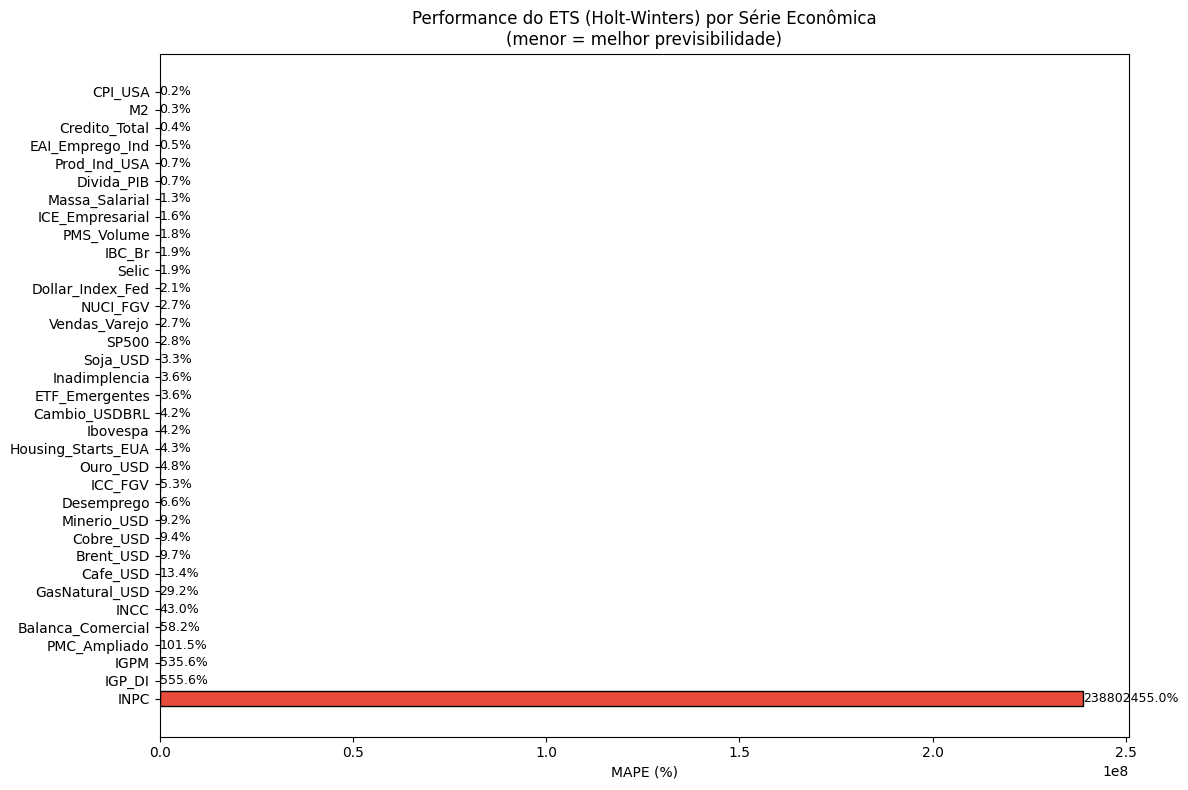

In [ ]:
# ── Gráfico: Ranking MAPE por Série ──
sorted_df = results_df.sort_values('MAPE (%)')

fig, ax = plt.subplots(figsize=(12, 8))

cores = ['#2ecc71' if m < 10 else '#3498db' if m < 20 else '#f39c12' if m < 30 else '#e74c3c'
         for m in sorted_df['MAPE (%)']]

bars = ax.barh(range(len(sorted_df)), sorted_df['MAPE (%)'],
               color=cores, edgecolor='white', height=0.7)
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df.index)
ax.invert_yaxis()
ax.set_xlabel('MAPE (%)')
ax.set_title(f'ETS (Holt-Winters) — MAPE por Série\n(Walk-Forward, h={HORIZON}, teste={TEST_SIZE} meses)',
             fontsize=13, fontweight='bold')
ax.axvline(x=sorted_df['MAPE (%)'].mean(), color='red', linestyle='--',
           label=f'Média: {sorted_df["MAPE (%)"].mean():.1f}%')
ax.legend(loc='lower right')

# Valores nas barras
for i, (bar, val) in enumerate(zip(bars, sorted_df['MAPE (%)'])):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ets_mape_por_serie.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico salvo: ets_mape_por_serie.png")

## 8. Visualização: Real vs. Projetado (Top 6 Séries)

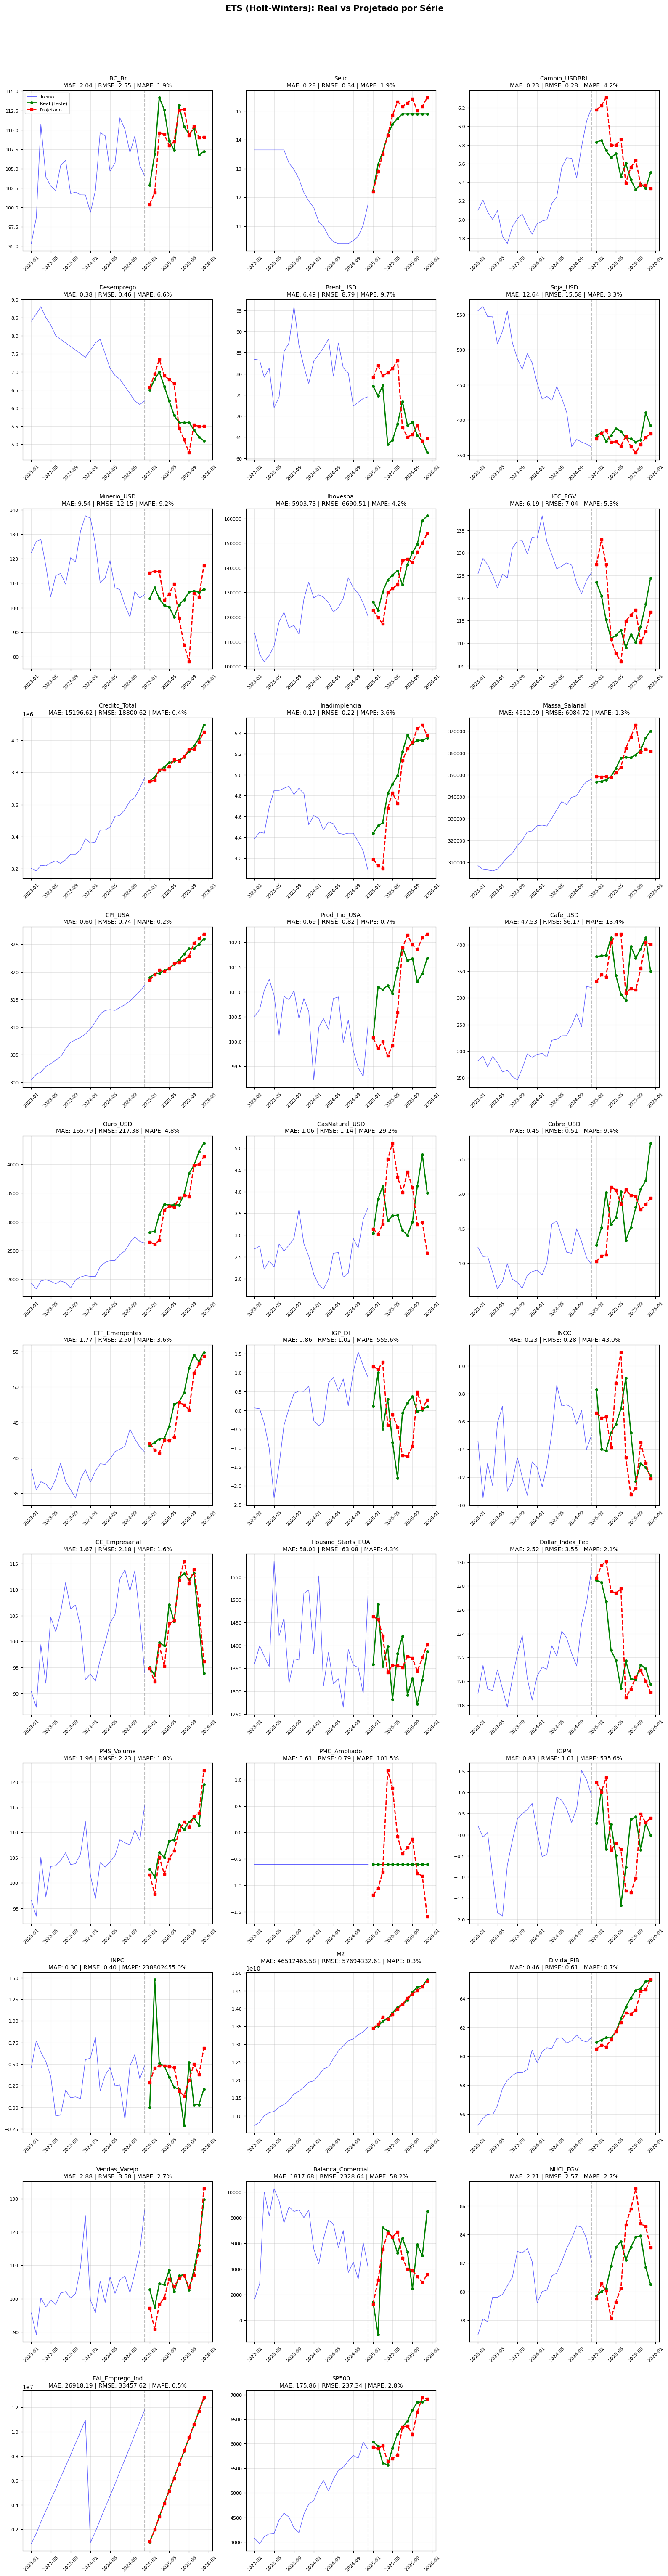


📊 Gráficos gerados para 35 séries


In [ ]:
# ── Gráfico: Real vs. Projetado (Top 6 Séries por MAPE) ──
top6 = sorted_df.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, sn in zip(axes.flatten(), top6):
    data = all_results[sn]

    # Contexto: últimos 24 meses de treino
    train_ctx = data['train_series'].iloc[-24:]
    ax.plot(train_ctx.index, train_ctx.values, 'b-',
            label='Treino', linewidth=1, alpha=0.5)

    # Valores reais (teste)
    ax.plot(data['dates'], data['actuals'], 'b-o',
            label='Real', markersize=4, linewidth=2)

    # Previsões do modelo
    ax.plot(data['dates'], data['forecasts'], 'r--s',
            label='Previsão', markersize=4, linewidth=2)

    # Separador treino/teste
    ax.axvline(x=train_ctx.index[-1], color='gray', linestyle='--', alpha=0.5)

    ax.set_title(f"{sn}\nMAPE: {data['mape']:.1f}%", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

axes.flatten()[0].legend(fontsize=8)
fig.suptitle('ETS (Holt-Winters) — Real vs. Projetado (6 Melhores Séries)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig('ets_previsoes.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfico salvo: ets_previsoes.png")

## 9. Exportação de Resultados

In [9]:
# Salvar resultados com nomes padronizados para compatibilidade com consolidação
results_export = results_df.reset_index()
results_export.columns = ['Serie', 'MAE', 'RMSE', 'MAPE', 'N_Pontos', 'Classificacao']
results_export.to_csv('resultados_ets.csv', index=False)
print("💾 Resultados salvos em 'resultados_ets.csv'")
print(f"   Colunas: {list(results_export.columns)}")

# Salvar previsões individuais (Serie, Data, Previsao) para análises complementares
previsoes_rows = []
for serie, data in all_results.items():
    for d, p in zip(data['dates'], data['forecasts']):
        previsoes_rows.append({'Serie': serie, 'Data': str(d)[:10], 'Previsao': p})
df_prev = pd.DataFrame(previsoes_rows)
df_prev.to_csv('previsoes_ets.csv', index=False)
print(f"💾 Previsões salvas em 'previsoes_ets.csv' ({len(df_prev)} linhas)")

💾 Resultados salvos em 'resultados_ets.csv'
   Colunas: ['Serie', 'MAE', 'RMSE', 'MAPE', 'N_Pontos', 'Classificacao']
💾 Previsões salvas em 'previsoes_ets.csv' (420 linhas)
